In [ ]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
'''Exercise 1 – Build Your MLP Using TensorFlow
Create the same 2-layer MLP using TensorFlow/Keras.

Step 1 – Import Libraries'''
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [ ]:
'''Step 2 – Create a Small Dataset
Let's predict Pass (1) or Fail (0) based on:
Study Hours
Attendance'''
import numpy as np

X = np.array([
    [2, 50],
    [3, 60],
    [4, 65],
    [5, 70],
    [6, 75],
    [7, 80],
    [8, 85],
    [9, 90]
])

y = np.array([
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1
])

In [ ]:
'''Step 3 – Build the Neural Network'''
model = Sequential([
    Dense(4, activation="relu", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

'''Explanation:
Input (2 Features)
↓
Hidden Layer (4 Neurons)
↓
Output Layer (1 Neuron)'''

'Explanation:\nInput (2 Features)\n↓\nHidden Layer (4 Neurons)\n↓\nOutput Layer (1 Neuron)'

In [ ]:
'''Step 4 – View the Model'''
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 4)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               5 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
'''Step 5 – Compile the Model'''
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
'''Step 6 – Train the Model'''
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - loss: 30.6314
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.5000 - loss: 30.4934
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5000 - loss: 30.3556
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5000 - loss: 30.2181
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5000 - loss: 30.0809
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5000 - loss: 29.9439
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5000 - loss: 29.8071
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5000 - loss: 29.6706
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5000 - loss: 29.5342
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5000 - loss: 29.3979
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5000 - loss: 29.2618
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - ac

In [ ]:
'''Step 7 – Make Predictions'''
prediction = model.predict(X)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
[[4.1203846e-12]
 [3.5407078e-14]
 [4.6662681e-15]
 [5.1913961e-16]
 [5.7675195e-17]
 [6.4075788e-18]
 [7.1186693e-19]
 [7.9086751e-20]]


In [ ]:
'''These are probabilities.
Anything above 0.5 is classified as Pass.'''

'These are probabilities.\nAnything above 0.5 is classified as Pass.'

In [ ]:
'''Step 8 – Predict a New Student'''
new_student = np.array([[7, 78]])

prediction = model.predict(new_student)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
[[1.897998e-17]]


In [ ]:
'''Exercise 2 – Model with Mean Squared Error'''
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Dataset
X = np.array([
    [2,50],
    [3,60],
    [4,65],
    [5,70],
    [6,75],
    [7,80],
    [8,85],
    [9,90]
])

y = np.array([0,0,0,0,1,1,1,1])

# Model
model_mse = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model_mse.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)

history_mse = model_mse.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

# Evaluate
loss_mse, acc_mse = model_mse.evaluate(X, y, verbose=0)

print("===== MSE MODEL =====")
print("Loss :", loss_mse)
print("Accuracy :", acc_mse)



===== MSE MODEL =====
Loss : 0.45224350690841675
Accuracy : 0.5


In [ ]:
'''Make Predictions with SME '''
print("\nPredictions:")
print(model_mse.predict(X))


Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
[[0.9256242 ]
 [0.9520865 ]
 [0.9593188 ]
 [0.96549904]
 [0.9707689 ]
 [0.97525454]
 [0.97906667]
 [0.9823021 ]]


In [ ]:
'''Exercise 3 - import TensorFlow's SGD optimizer, SGD is Gradient Descent (technically stochastic gradient descent).'''
from tensorflow.keras.optimizers import SGD

optimizer = SGD(learning_rate=0.01)

In [ ]:
'''Exercise 4 – build model with Gradient Descent'''
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [2,50],
    [3,60],
    [4,65],
    [5,70],
    [6,75],
    [7,80],
    [8,85],
    [9,90]
], dtype=np.float32)

# Normalize
X[:,0] = X[:,0] / 9
X[:,1] = X[:,1] / 90

y = np.array([0,0,0,0,1,1,1,1], dtype=np.float32)

# Model
model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# Gradient Descent Optimizer
optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=['accuracy']
)

history = model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 998ms/step - accuracy: 0.2500 - loss: 0.2866
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2500 - loss: 0.2865
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2500 - loss: 0.2865
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.2500 - loss: 0.2864
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.2500 - loss: 0.2863
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2500 - loss: 0.2862
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2500 - loss: 0.2862
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2500 - loss: 0.2861
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2500 - loss: 0.2860
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2500 - loss: 0.2859
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.2500 - loss: 0.2859
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.

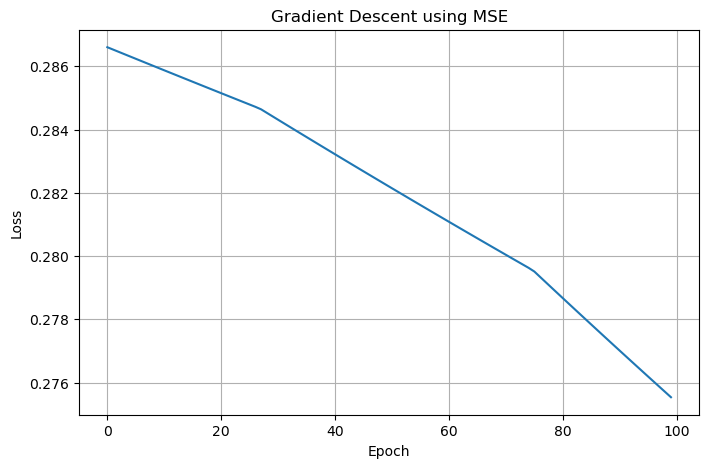

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.title("Gradient Descent using MSE")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()